# Assignment 6 - RNN dự đoán chuỗi thời gian

Notebook dùng hai bộ dữ liệu thật đã có trong `../data`: `all_stocks_5yr.csv.zip` và `online_retail_II.csv.zip`. Nội dung gồm lý thuyết RNN/LSTM, biểu diễn hàm, EDA/phân bố, tiền xử lý, PyTorch, Keras, đánh giá và liên hệ deployment.

Bài toán: dùng 30 ngày gần nhất để dự đoán giá trị ngày kế tiếp. Với chứng khoán, chọn `AAPL` và mục tiêu là giá đóng cửa. Với bán lẻ, mục tiêu là số hóa đơn khác nhau mỗi ngày sau khi loại giao dịch hủy và dữ liệu không hợp lệ.

## 1. Lý thuyết RNN/LSTM

Với chuỗi $x_1, ..., x_T$, RNN cập nhật trạng thái:

$$h_t = \tanh(W_xx_t + W_hh_{t-1} + b_h), \quad \hat y_t = W_yh_t+b_y$$

RNN truyền `hidden state` từ quá khứ nên phù hợp với dữ liệu có thứ tự. Tuy nhiên, khi chuỗi dài, gradient có thể bị tiêu biến. LSTM thêm `cell state` và các cổng:

$$f_t=\sigma(W_f[x_t,h_{t-1}]+b_f)$$
$$i_t=\sigma(W_i[x_t,h_{t-1}]+b_i),\quad c_t=f_t\odot c_{t-1}+i_t\odot\tilde c_t$$
$$o_t=\sigma(W_o[x_t,h_{t-1}]+b_o),\quad h_t=o_t\odot\tanh(c_t)$$

Mô hình trong bài là many-to-one: tensor `(batch, 30, 1)` đi qua LSTM, lấy output tại bước thứ 30 và hồi quy một số thực.

In [1]:
from pathlib import Path
import random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
random.seed(SEED); np.random.seed(SEED)
ROOT = Path.cwd()
if not (ROOT / 'data').exists(): ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'; MODEL_DIR = ROOT / 'models'
sns.set_theme(style='whitegrid', context='notebook')
print(DATA_DIR)

/home/dau/assignment2/assignment6/data


## 2. Đọc và mô tả dữ liệu thật

Bộ cổ phiếu có các cột `date, open, high, low, close, volume, Name`. `Name` là mã cổ phiếu; các giá OHLC mô tả diễn biến trong ngày và `volume` là khối lượng. Ta chọn `AAPL`, mục tiêu `close`.

Bộ Online Retail II có `Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country`. Hóa đơn bắt đầu bằng `C` là giao dịch hủy; ta loại chúng cùng các dòng có `Quantity <= 0` hoặc `Price <= 0`. Sau đó nhóm theo ngày và đếm `Invoice` duy nhất. Đây là cách chuyển dữ liệu giao dịch dạng event thành chuỗi thời gian.

In [2]:
stock_raw = pd.read_csv(DATA_DIR / 'all_stocks_5yr.csv.zip', compression='zip', parse_dates=['date'])
retail_raw = pd.read_csv(DATA_DIR / 'online_retail_II.csv.zip', compression='zip', parse_dates=['InvoiceDate'])
print('Stock:', stock_raw.shape, 'Retail:', retail_raw.shape)
display(stock_raw.head()); display(retail_raw.head())

stock = (stock_raw[stock_raw['Name'].eq('AAPL')].sort_values('date')[['date','close']]
         .rename(columns={'close':'value'}).dropna())
retail = retail_raw.copy(); retail['Invoice'] = retail['Invoice'].astype(str)
retail = retail[~retail['Invoice'].str.startswith('C', na=False)]
retail = retail[(retail['Quantity'] > 0) & (retail['Price'] > 0)].dropna(subset=['InvoiceDate','Invoice'])
transactions = (retail.assign(date=retail['InvoiceDate'].dt.floor('D'))
                .groupby('date', as_index=False)['Invoice'].nunique()
                .rename(columns={'Invoice':'value'}).sort_values('date'))
print('AAPL:', len(stock), stock.date.min().date(), '->', stock.date.max().date())
print('Transactions:', len(transactions), transactions.date.min().date(), '->', transactions.date.max().date())

Stock: (619040, 7) Retail: (1067371, 8)


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


AAPL: 1259 2013-02-08 -> 2018-02-07
Transactions: 604 2009-12-01 -> 2011-12-09


## 3. EDA và phân bố

Không chỉ xem trung bình, ta xem median, phân vị, độ lệch (`skew`), kurtosis, missing values, xu hướng và outlier. Giá cổ phiếu là biến liên tục; số hóa đơn là biến đếm, có phân bố rời rạc. Do dữ liệu có thứ tự, line chart quan trọng hơn một histogram đơn độc.

AAPL close


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,skew,kurtosis
value,1259.0,109.066698,30.556812,55.7899,58.81457,62.54894,84.83065,109.01,127.12,166.898,175.0042,179.26,0,0.289868,-0.609264


Daily unique invoices


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,skew,kurtosis
value,604.0,66.352649,24.777815,11.0,20.03,30.0,49.0,63.0,80.0,115.85,132.0,153.0,0,0.680322,0.374042


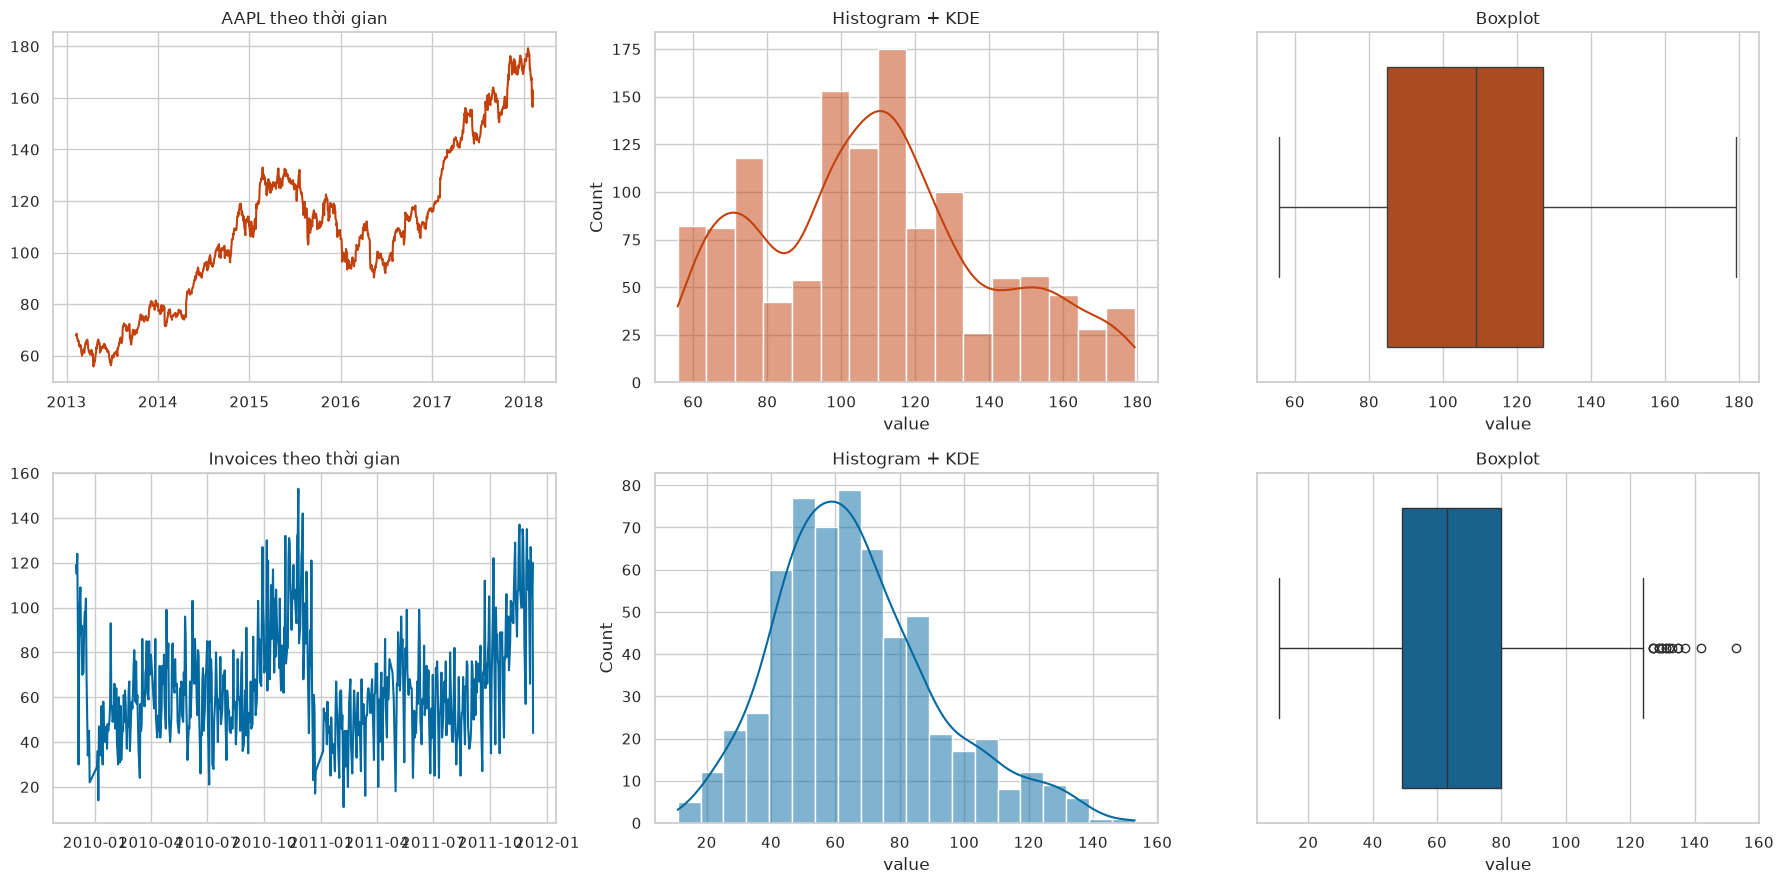

In [3]:
def summary(frame, name):
    result = frame['value'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).to_frame().T
    result['missing'] = frame['value'].isna().sum(); result['skew'] = frame['value'].skew(); result['kurtosis'] = frame['value'].kurtosis()
    print(name); display(result)
summary(stock, 'AAPL close'); summary(transactions, 'Daily unique invoices')

fig, ax = plt.subplots(2, 3, figsize=(18,9))
for r, (frame, title, color) in enumerate([(stock,'AAPL','#c2410c'),(transactions,'Invoices','#0369a1')]):
    ax[r,0].plot(frame.date, frame.value, color=color); ax[r,0].set_title(title + ' theo thời gian')
    sns.histplot(frame.value, kde=True, ax=ax[r,1], color=color); ax[r,1].set_title('Histogram + KDE')
    sns.boxplot(x=frame.value, ax=ax[r,2], color=color); ax[r,2].set_title('Boxplot')
plt.tight_layout(); plt.show()

## 4. Chia theo thời gian, chuẩn hóa và sliding window

Dùng 80% đầu cho train, 20% cuối cho test và không shuffle. Scaler chỉ fit trên train để tránh data leakage. Với window 30:

$$X_i=[y_{i-30},...,y_{i-1}],\quad target_i=y_i$$

Sau đó shape là `(samples, time_steps, features) = (samples, 30, 1)`.

In [4]:
WINDOW = 30
def windows(values, window=WINDOW):
    X,y=[],[]
    for i in range(window,len(values)): X.append(values[i-window:i]); y.append(values[i])
    return np.asarray(X,dtype='float32'), np.asarray(y,dtype='float32')
def prepare(frame):
    values=frame[['value']].to_numpy(dtype='float32'); split=int(len(values)*.8)
    scaler=MinMaxScaler(); scaler.fit(values[:split]); scaled=scaler.transform(values).astype('float32')
    X,y=windows(scaled); end=split-WINDOW
    return X[:end],y[:end],X[end:],y[end:],scaler
prepared={'stock':prepare(stock),'transactions':prepare(transactions)}
for name,(Xtr,ytr,Xte,yte,_) in prepared.items(): print(name, Xtr.shape, ytr.shape, Xte.shape, yte.shape)

stock (977, 30, 1) (977, 1) (252, 30, 1) (252, 1)
transactions (453, 30, 1) (453, 1) (121, 30, 1) (121, 1)


## 5. PyTorch LSTM

Kiến trúc: `LSTM(1 -> 32) -> Linear(32 -> 16) -> ReLU -> Linear(16 -> 1)`. Loss là MSE trên dữ liệu chuẩn hóa, optimizer Adam. Khi tính metrics, dự đoán được đưa về đơn vị gốc.

In [5]:
import torch
from torch import nn
torch.manual_seed(SEED)
class TorchLSTM(nn.Module):
    def __init__(self):
        super().__init__(); self.lstm=nn.LSTM(1,32,batch_first=True); self.head=nn.Sequential(nn.Linear(32,16),nn.ReLU(),nn.Linear(16,1))
    def forward(self,x):
        out,_=self.lstm(x); return self.head(out[:,-1,:])
def train_torch(frame, epochs=20):
    Xtr,ytr,Xte,yte,scaler=prepare(frame); Xtr=torch.tensor(Xtr); ytr=torch.tensor(ytr); Xte=torch.tensor(Xte)
    model=TorchLSTM(); opt=torch.optim.Adam(model.parameters(),lr=.003); loss_fn=nn.MSELoss(); history=[]
    for _ in range(epochs):
        opt.zero_grad(); loss=loss_fn(model(Xtr),ytr); loss.backward(); opt.step(); history.append(float(loss.detach()))
    model.eval();
    with torch.no_grad(): pred_scaled=model(Xte).numpy()
    return model,history,scaler.inverse_transform(yte).ravel(),scaler.inverse_transform(pred_scaled).ravel()
torch_results={}
for name,frame in [('stock',stock),('transactions',transactions)]:
    t=time.perf_counter(); m,h,a,p=train_torch(frame); torch_results[name]={'model':m,'history':h,'actual':a,'prediction':p,'seconds':time.perf_counter()-t}
    print(name, 'final loss=',round(h[-1],6))

stock final loss= 0.04636


transactions final loss= 0.027807


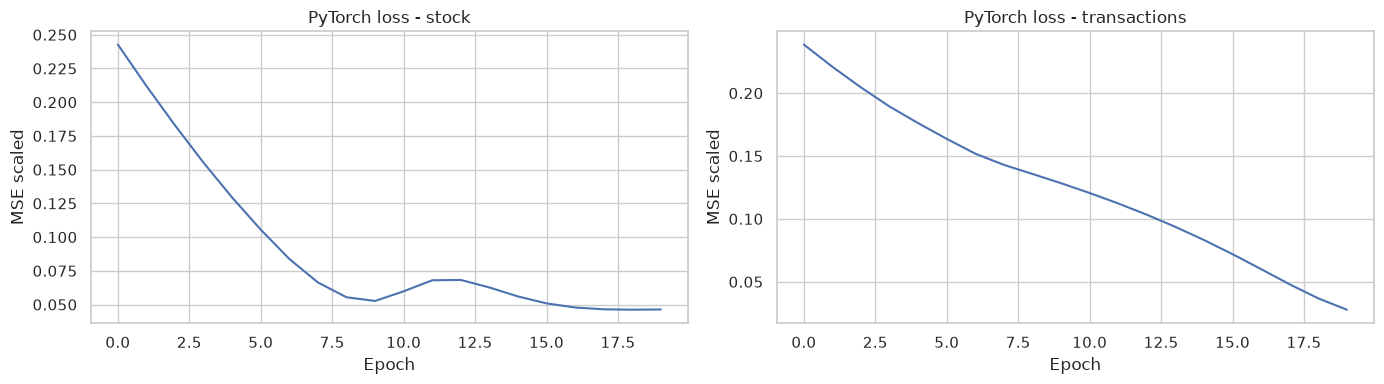

In [6]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
for axis,(name,r) in zip(ax,torch_results.items()): axis.plot(r['history']); axis.set_title('PyTorch loss - '+name); axis.set_xlabel('Epoch'); axis.set_ylabel('MSE scaled')
plt.tight_layout(); plt.show()

## 6. Keras/TensorFlow LSTM

Keras dùng đúng số lớp và số units như PyTorch để so sánh hợp lý. `model.fit` học trên train, còn test chỉ dùng sau huấn luyện.

In [7]:
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
def keras_model():
    model=tf.keras.Sequential([tf.keras.layers.Input(shape=(WINDOW,1)),tf.keras.layers.LSTM(32),tf.keras.layers.Dense(16,activation='relu'),tf.keras.layers.Dense(1)])
    model.compile(optimizer=tf.keras.optimizers.Adam(.003),loss='mse'); return model
def train_keras(frame,epochs=20):
    Xtr,ytr,Xte,yte,scaler=prepare(frame); model=keras_model(); hist=model.fit(Xtr,ytr,epochs=epochs,batch_size=64,verbose=0)
    pred_scaled=model.predict(Xte,verbose=0); return model,hist.history['loss'],scaler.inverse_transform(yte).ravel(),scaler.inverse_transform(pred_scaled).ravel()
keras_results={}
for name,frame in [('stock',stock),('transactions',transactions)]:
    t=time.perf_counter(); m,h,a,p=train_keras(frame); keras_results[name]={'model':m,'history':h,'actual':a,'prediction':p,'seconds':time.perf_counter()-t}
    print(name, 'final loss=',round(h[-1],6))

I0000 00:00:1790745901.134182  311275 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790745901.232459  311275 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


stock final loss= 0.00098


transactions final loss= 0.014996


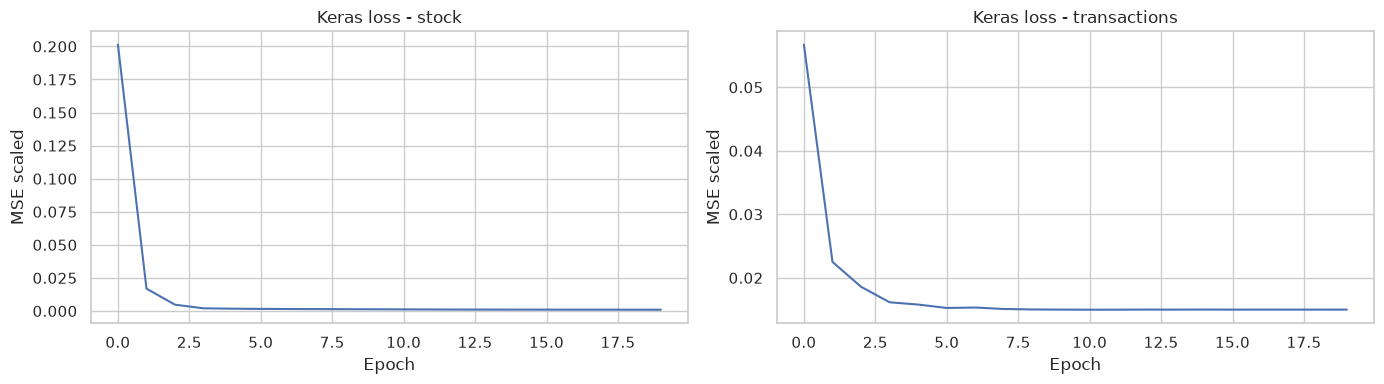

In [8]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
for axis,(name,r) in zip(ax,keras_results.items()): axis.plot(r['history']); axis.set_title('Keras loss - '+name); axis.set_xlabel('Epoch'); axis.set_ylabel('MSE scaled')
plt.tight_layout(); plt.show()

## 7. Metrics và so sánh

MAE có cùng đơn vị với target; RMSE phạt lỗi lớn; MAPE biểu diễn phần trăm và chỉ ổn định khi target không gần 0. Không dùng accuracy cho hồi quy. So sánh PyTorch với Keras trên cùng dataset, không so trực tiếp số tuyệt đối giữa stock và transactions vì khác đơn vị.

,Framework,Dataset,Seconds,MAE,RMSE,MAPE (%)
2,Keras,stock,12.61,6.885,8.165,4.26
0,PyTorch,stock,3.71,47.464,48.507,30.18
3,Keras,transactions,8.58,15.318,19.824,24.53
1,PyTorch,transactions,1.11,23.799,29.839,31.19


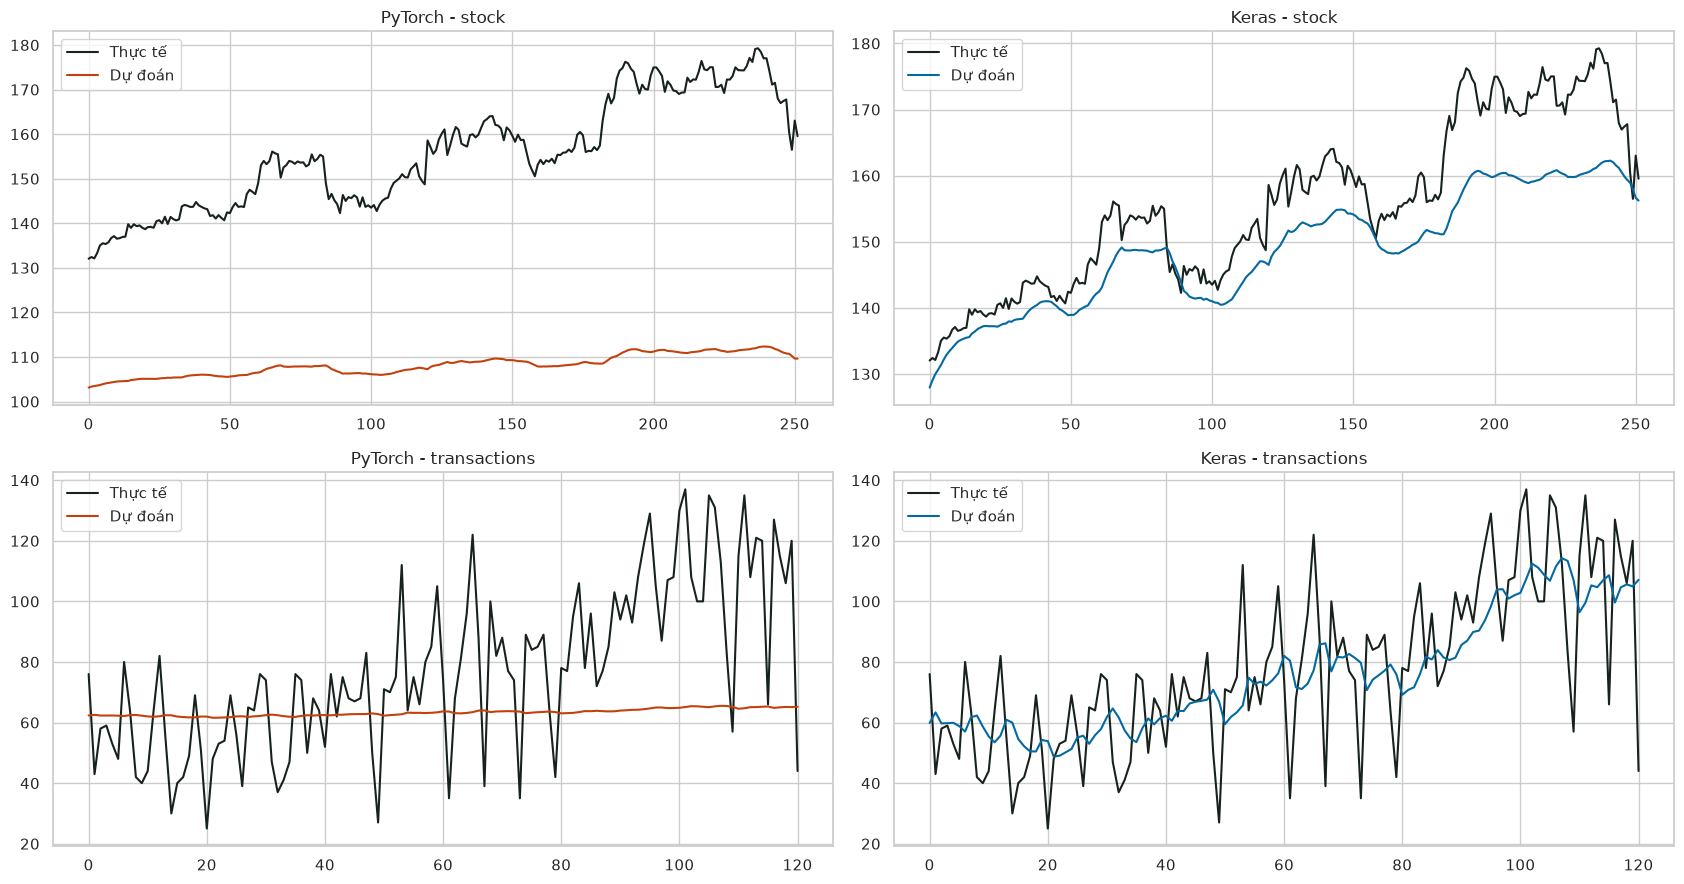

In [9]:
def metrics(actual,pred):
    return {'MAE':mean_absolute_error(actual,pred),'RMSE':np.sqrt(mean_squared_error(actual,pred)),'MAPE (%)':np.mean(np.abs((actual-pred)/np.maximum(np.abs(actual),1e-8)))*100}
rows=[]
for framework,results in [('PyTorch',torch_results),('Keras',keras_results)]:
    for dataset,r in results.items():
        row={'Framework':framework,'Dataset':dataset,'Seconds':r['seconds']}; row.update(metrics(r['actual'],r['prediction'])); rows.append(row)
comparison=pd.DataFrame(rows).sort_values(['Dataset','MAE']); display(comparison.style.format({'MAE':'{:.3f}','RMSE':'{:.3f}','MAPE (%)':'{:.2f}','Seconds':'{:.2f}'}))
fig,ax=plt.subplots(2,2,figsize=(17,9))
for row,name in enumerate(['stock','transactions']):
    for col,(fw,res,color) in enumerate([('PyTorch',torch_results,'#c2410c'),('Keras',keras_results,'#0369a1')]):
        ax[row,col].plot(res[name]['actual'],label='Thực tế',color='#17221c'); ax[row,col].plot(res[name]['prediction'],label='Dự đoán',color=color); ax[row,col].set_title(f'{fw} - {name}'); ax[row,col].legend()
plt.tight_layout(); plt.show()

## 8. Lưu kết quả và deployment

Có thể lưu model và bảng kết quả để web hoặc báo cáo dùng lại. Hai server đã có sẵn trong dự án:

```bash
conda activate assignment2
cd /home/dau/assignment2/assignment6
uvicorn web.pytorch_app:app --app-dir /home/dau/assignment2/assignment6 --port 8001
uvicorn web.keras_app:app --app-dir /home/dau/assignment2/assignment6 --port 8002
```

Web PyTorch: `http://127.0.0.1:8001`; web Keras: `http://127.0.0.1:8002`. API nhận dataset và 30 giá trị gần nhất, trả về dự báo ngày kế tiếp.

In [10]:
MODEL_DIR.mkdir(exist_ok=True)
torch.save(torch_results['stock']['model'].state_dict(), MODEL_DIR/'pytorch_stock_notebook.pth')
keras_results['stock']['model'].save(MODEL_DIR/'keras_stock_notebook.keras')
comparison.to_csv(MODEL_DIR/'notebook_comparison.csv',index=False)
print('Đã lưu model và comparison.csv vào', MODEL_DIR)

Đã lưu model và comparison.csv vào /home/dau/assignment2/assignment6/models


## Kết luận

Quy trình đã đi từ dữ liệu thật -> EDA -> làm sạch -> tổng hợp chuỗi -> chuẩn hóa chống leakage -> sliding window -> LSTM PyTorch -> LSTM Keras -> đánh giá -> biểu đồ -> deployment. LSTM học được quan hệ theo thời gian tốt hơn một mô hình chỉ nhìn từng dòng độc lập. Tuy nhiên, dự báo chứng khoán vẫn khó vì chịu ảnh hưởng của tin tức và biến ngoại sinh; retail chịu ảnh hưởng ngày lễ, khuyến mại và danh mục sản phẩm. Vì vậy nên dùng thêm walk-forward validation và nhiều seed khi làm nghiên cứu mở rộng.